# Drowsy Driver Detection — PyTorch + ROCm (AMD GPU) v2

| Component | Detail |
|---|---|
| Backbone | EfficientNet-V2-S (ImageNet pretrained) |
| Framework | PyTorch + ROCm |
| Training | 2-phase (warm-up head → full fine-tune) |
| Speed | Optimized for AMD MI300 class GPU |

In [41]:
# ── Cell 1: Imports & GPU check ────────────────────────────────────────────────
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import torchvision.transforms as T
import timm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import cv2, os, json, random
from PIL import Image
from datetime import datetime


torch.manual_seed(42)
np.random.seed(42)
random.seed(42)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'PyTorch : {torch.__version__}')
print(f'Device  : {DEVICE}')
if torch.cuda.is_available():
    print(f'GPU     : {torch.cuda.get_device_name(0)}')

PyTorch : 2.8.0+gitb2fb688
Device  : cuda
GPU     : 


In [61]:
print(IMG_SIZE)

224


In [52]:
# ── Cell 2: Config ─────────────────────────────────────────────────────────────
DATASET_DIR = '/workspace/FaceDetector/drowsiness.v11i.multiclass'
TRAIN_DIR   = os.path.join(DATASET_DIR, 'train')
VALID_DIR   = os.path.join(DATASET_DIR, 'valid')
TEST_DIR    = os.path.join(DATASET_DIR, 'test')

IMG_SIZE   = 224
BATCH_SIZE = 32    # reduce from 64 since images are bigger now
EPOCHS_P1  = 20
EPOCHS_P2  = 50
LR_P1      = 1e-3
LR_P2      = 3e-5

# 2-phase training
LR_P1 = 3e-4   # head warm-up
LR_P2 = 5e-5   # full fine-tune

EPOCHS_P1 = 15   # was 10
EPOCHS_P2 = 35   # was 25

ALERT_LABELS = {'drowsy', 'head drop', 'yawn', 'distracted'}

OUTPUT_DIR = os.path.join(os.getcwd(), 'output')
os.makedirs(OUTPUT_DIR, exist_ok=True)
MODEL_PATH = os.path.join(OUTPUT_DIR, 'best_drowsy_model.pth')
LABEL_PATH = os.path.join(OUTPUT_DIR, 'class_labels.json')

if not os.path.exists(DATASET_DIR):
    raise FileNotFoundError(f"Dataset not found at '{DATASET_DIR}'")
print('Config OK.')

Config OK.


Classes (5): ['awake', 'distracted', 'drowsy', 'head drop', 'yawn']
Train (balanced): 2453 | Val: 445 | Test: 380


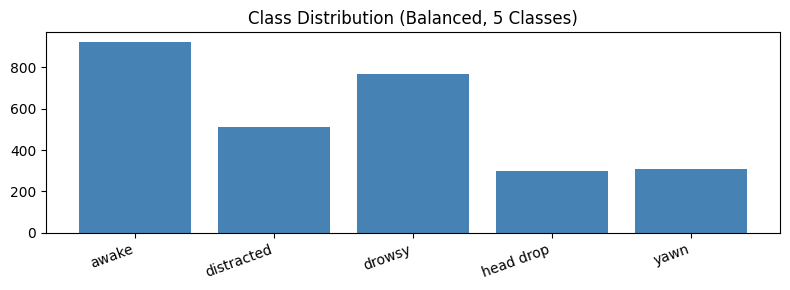

Counts: {'awake': np.int64(923), 'distracted': np.int64(514), 'drowsy': np.int64(770), 'head drop': np.int64(300), 'yawn': np.int64(309)}


In [53]:
# ── Cell 3: Dataset ────────────────────────────────────────────────────────────
def read_csv(split_dir):
    df = pd.read_csv(os.path.join(split_dir, '_classes.csv'))
    df.columns = df.columns.str.strip()
    return df

train_df = read_csv(TRAIN_DIR)
valid_df = read_csv(VALID_DIR)
test_df  = read_csv(TEST_DIR)

filename_col = train_df.columns[0]

# ── Drop smoking and phone ─────────────────────────────────────────────────────
KEEP_CLASSES = ['awake', 'distracted', 'drowsy', 'head drop', 'yawn']
class_cols   = KEEP_CLASSES
num_classes  = len(class_cols)
label_map    = {i: c for i, c in enumerate(class_cols)}

with open(LABEL_PATH, 'w') as f:
    json.dump({str(k): v for k, v in label_map.items()}, f, indent=2)

# Keep only rows that belong to one of our 5 classes (drop smoking/phone rows)
train_df = train_df[train_df[class_cols].sum(axis=1) > 0][
    [train_df.columns[0]] + class_cols].reset_index(drop=True)
valid_df = valid_df[valid_df[class_cols].sum(axis=1) > 0][
    [valid_df.columns[0]] + class_cols].reset_index(drop=True)
test_df  = test_df[test_df[class_cols].sum(axis=1) > 0][
    [test_df.columns[0]] + class_cols].reset_index(drop=True)

# ── Balance with custom caps ───────────────────────────────────────────────────
CAPS = {
    'awake':       850,
    'distracted':  500,
    'drowsy':      700,
    'head drop':   300,  # keep all, it's the rarest
    'yawn':        309,  # keep all
}

balanced_rows = []
for col in class_cols:
    rows = train_df[train_df[col] == 1]
    cap  = CAPS[col]
    if len(rows) > cap:
        rows = rows.sample(cap, random_state=42)
    balanced_rows.append(rows)

train_df = pd.concat(balanced_rows).drop_duplicates().reset_index(drop=True)

print(f'Classes ({num_classes}): {class_cols}')
print(f'Train (balanced): {len(train_df)} | Val: {len(valid_df)} | Test: {len(test_df)}')

counts = train_df[class_cols].sum().values
fig, ax = plt.subplots(figsize=(8, 3))
ax.bar(class_cols, counts, color='steelblue')
ax.set_title('Class Distribution (Balanced, 5 Classes)')
plt.xticks(rotation=20, ha='right')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'class_distribution.png'), dpi=120)
plt.show()
print('Counts:', dict(zip(class_cols, counts.astype(int))))

In [54]:
# ── Cell 4: DataLoader ─────────────────────────────────────────────────────────
# Removed OpenCV from workers entirely — PIL only, no segfault risk

class DrowsinessDataset(Dataset):
    def __init__(self, split_dir, df, transform=None):
        self.split_dir = split_dir
        self.df        = df.reset_index(drop=True)
        self.transform = transform

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row      = self.df.iloc[idx]
        img_path = os.path.join(self.split_dir, row[filename_col])
        try:
            img = Image.open(img_path).convert('RGB')
            # Simple center-crop as face proxy (PIL only, no OpenCV)
            w, h = img.size
            s    = min(w, h)
            img  = img.crop(((w-s)//2, (h-s)//2, (w+s)//2, (h+s)//2))
            img  = img.resize((IMG_SIZE, IMG_SIZE), Image.BILINEAR)
        except Exception:
            img  = Image.fromarray(np.zeros((IMG_SIZE, IMG_SIZE, 3), dtype=np.uint8))

        if self.transform:
            img = self.transform(img)
        label = torch.tensor(row[class_cols].values.astype('float32'))
        return img, label

MEAN = [0.485, 0.456, 0.406]
STD  = [0.229, 0.224, 0.225]

train_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.RandomHorizontalFlip(),
    T.RandomRotation(10),
    T.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.1),
    T.RandomAffine(degrees=0, translate=(0.1, 0.1)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
val_tf = T.Compose([
    T.Resize((IMG_SIZE, IMG_SIZE)),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

train_ds = DrowsinessDataset(TRAIN_DIR, train_df, transform=train_tf)
val_ds   = DrowsinessDataset(VALID_DIR, valid_df, transform=val_tf)
test_ds  = DrowsinessDataset(TEST_DIR,  test_df,  transform=val_tf)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                          num_workers=4, pin_memory=True, prefetch_factor=2)
val_loader   = DataLoader(val_ds,   batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)
test_loader  = DataLoader(test_ds,  batch_size=BATCH_SIZE, shuffle=False,
                          num_workers=4, pin_memory=True)

print('DataLoaders ready.')

DataLoaders ready.


In [55]:
# ── Cell 5: Model ──────────────────────────────────────────────────────────────
class DrowsyModel(nn.Module):
    def __init__(self, num_classes, embed_dim=EMBED_DIM):
        super().__init__()
        self.backbone = timm.create_model(
            'tf_efficientnetv2_s',
            pretrained=True,
            num_classes=0,
            global_pool='avg'
        )
        in_features = self.backbone.num_features
        self.head = nn.Sequential(
            nn.BatchNorm1d(in_features),
            nn.Linear(in_features, embed_dim),
            nn.ReLU(),
            nn.Dropout(0.5),
            nn.Linear(embed_dim, num_classes)
        )

    def forward(self, x):
        return self.head(self.backbone(x))

    def freeze_backbone(self):
        for p in self.backbone.parameters():
            p.requires_grad = False

    def unfreeze_all(self):
        for p in self.backbone.parameters():
            p.requires_grad = True
        # Keep BN frozen — critical for stable fine-tuning
        for m in self.backbone.modules():
            if isinstance(m, nn.BatchNorm2d):
                for p in m.parameters():
                    p.requires_grad = False

model = DrowsyModel(num_classes).to(DEVICE)
total     = sum(p.numel() for p in model.parameters())
trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total params    : {total:,}')
print(f'Trainable params: {trainable:,}')

Total params    : 20,509,269
Trainable params: 20,509,269


In [56]:
# ── Cell 6: Loss, training loop ────────────────────────────────────────────────
import torch.nn.functional as F

# Compute class weights to counter imbalance
counts  = train_df[class_cols].sum().values.astype('float32')
weights = torch.tensor(1.0 / (counts + 1e-6), dtype=torch.float32).to(DEVICE)
weights = weights / weights.sum() * len(counts)  # normalize to num_classes
print('Class weights:', {c: f'{w:.2f}' for c, w in zip(class_cols, weights.cpu().numpy())})

def mixup(imgs, labels, alpha=0.4):
    lam   = np.random.beta(alpha, alpha)
    idx   = torch.randperm(imgs.size(0))
    imgs2 = lam * imgs + (1 - lam) * imgs[idx]
    labs2 = lam * labels + (1 - lam) * labels[idx]
    return imgs2, labs2

def smooth_loss(preds, targets, smoothing=0.0):
    log_probs = F.log_softmax(preds, dim=1)
    hard_idx  = targets.argmax(1)
    loss      = F.nll_loss(log_probs, hard_idx, weight=weights)
    if smoothing > 0:
        smooth = -(log_probs * weights.unsqueeze(0)).sum(1).mean()
        loss   = (1 - smoothing) * loss + smoothing * smooth
    return loss

def train_epoch(model, loader, optimizer, use_mixup=False, smoothing=0.1):
    model.train()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        if use_mixup:
            imgs, labels = mixup(imgs, labels)
        optimizer.zero_grad()
        preds = model(imgs)
        loss  = smooth_loss(preds, labels, smoothing)
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds.argmax(1) == labels.argmax(1)).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

@torch.no_grad()
def eval_epoch(model, loader):
    model.eval()
    total_loss, correct, total = 0, 0, 0
    for imgs, labels in loader:
        imgs, labels = imgs.to(DEVICE), labels.to(DEVICE)
        preds = model(imgs)
        loss  = smooth_loss(preds, labels)
        total_loss += loss.item() * imgs.size(0)
        correct    += (preds.argmax(1) == labels.argmax(1)).sum().item()
        total      += imgs.size(0)
    return total_loss / total, correct / total

def run_phase(model, train_loader, val_loader, optimizer, scheduler,
              epochs, phase_name, use_mixup=False, smoothing=0.1, patience=7):
    best_acc, no_improve = 0, 0
    history = {'train_loss':[], 'train_acc':[], 'val_loss':[], 'val_acc':[]}

    for epoch in range(1, epochs+1):
        tr_loss, tr_acc = train_epoch(model, train_loader, optimizer, use_mixup, smoothing)
        vl_loss, vl_acc = eval_epoch(model, val_loader)
        scheduler.step(vl_loss)

        history['train_loss'].append(tr_loss)
        history['train_acc'].append(tr_acc)
        history['val_loss'].append(vl_loss)
        history['val_acc'].append(vl_acc)

        print(f'[{phase_name}] Ep {epoch:02d}/{epochs} | '
              f'Train {tr_acc:.3f} ({tr_loss:.3f}) | '
              f'Val {vl_acc:.3f} ({vl_loss:.3f})'
              + (' ✓ best' if vl_acc > best_acc else ''))

        if vl_acc > best_acc:
            best_acc, no_improve = vl_acc, 0
            torch.save(model.state_dict(), MODEL_PATH)
        else:
            no_improve += 1
            if no_improve >= patience:
                print(f'  Early stop at epoch {epoch}')
                break

    model.load_state_dict(torch.load(MODEL_PATH))
    print(f'\n{phase_name} best val_acc: {best_acc:.4f}\n')
    return history

print('Training functions ready.')

Class weights: {'awake': '0.50', 'distracted': '0.89', 'drowsy': '0.60', 'head drop': '1.53', 'yawn': '1.48'}
Training functions ready.


In [57]:
# ── Cell 7: Phase 1 — head warm-up (frozen backbone) ──────────────────────────
# Goal: get the classification head to a good starting point quickly
# No mixup — backbone is frozen so we need clean gradients for the head
model.freeze_backbone()
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

opt1 = optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=LR_P1)
sch1 = optim.lr_scheduler.ReduceLROnPlateau(opt1, factor=0.3, patience=3, min_lr=1e-6)

hist1 = run_phase(model, train_loader, val_loader, opt1, sch1,
                  EPOCHS_P1, 'Phase 1 (head)', use_mixup=False, smoothing=0.1, patience=5)

Trainable params: 331,781
[Phase 1 (head)] Ep 01/15 | Train 0.398 (2.127) | Val 0.542 (1.309) ✓ best
[Phase 1 (head)] Ep 02/15 | Train 0.518 (1.992) | Val 0.503 (1.271)
[Phase 1 (head)] Ep 03/15 | Train 0.535 (1.942) | Val 0.557 (1.239) ✓ best
[Phase 1 (head)] Ep 04/15 | Train 0.586 (1.912) | Val 0.535 (1.214)
[Phase 1 (head)] Ep 05/15 | Train 0.575 (1.898) | Val 0.564 (1.181) ✓ best
[Phase 1 (head)] Ep 06/15 | Train 0.604 (1.881) | Val 0.544 (1.203)
[Phase 1 (head)] Ep 07/15 | Train 0.615 (1.878) | Val 0.566 (1.204) ✓ best
[Phase 1 (head)] Ep 08/15 | Train 0.612 (1.867) | Val 0.600 (1.178) ✓ best
[Phase 1 (head)] Ep 09/15 | Train 0.621 (1.855) | Val 0.528 (1.207)
[Phase 1 (head)] Ep 10/15 | Train 0.625 (1.846) | Val 0.571 (1.182)
[Phase 1 (head)] Ep 11/15 | Train 0.642 (1.842) | Val 0.616 (1.150) ✓ best
[Phase 1 (head)] Ep 12/15 | Train 0.642 (1.838) | Val 0.609 (1.162)
[Phase 1 (head)] Ep 13/15 | Train 0.653 (1.817) | Val 0.591 (1.172)
[Phase 1 (head)] Ep 14/15 | Train 0.657 (1.824) 

In [58]:
# ── Cell 8: Phase 2 — full fine-tune with Mixup ────────────────────────────────
# Unfreeze everything — this is where the real accuracy gains happen
# Mixup ON — helps generalize with small dataset
# Lower LR — careful updates to pretrained weights
model.unfreeze_all()
print(f'Trainable params: {sum(p.numel() for p in model.parameters() if p.requires_grad):,}')

opt2 = optim.AdamW(filter(lambda p: p.requires_grad, model.parameters()),
                   lr=LR_P2, weight_decay=1e-4)
sch2 = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=EPOCHS_P2, eta_min=1e-7)

hist2 = run_phase(model, train_loader, val_loader, opt2, sch2,
                  EPOCHS_P2, 'Phase 2 (full)', use_mixup=True, smoothing=0.05, patience=10)

Trainable params: 20,355,397
[Phase 2 (full)] Ep 01/35 | Train 0.589 (1.480) | Val 0.631 (1.041) ✓ best


/usr/local/lib/python3.12/dist-packages/torch/optim/lr_scheduler.py:209: UserWarning: The epoch parameter in `scheduler.step()` was not necessary and is being deprecated where possible. Please use `scheduler.step()` to step the scheduler. During the deprecation, if epoch is different from None, the closed form is used instead of the new chainable form, where available. Please open an issue if you are unable to replicate your use case: https://github.com/pytorch/pytorch/issues/new/choose.
  warnings.warn(EPOCH_DEPRECATION_WARNING, UserWarning)


[Phase 2 (full)] Ep 02/35 | Train 0.656 (1.384) | Val 0.611 (1.003)
[Phase 2 (full)] Ep 03/35 | Train 0.676 (1.392) | Val 0.600 (1.002)
[Phase 2 (full)] Ep 04/35 | Train 0.726 (1.307) | Val 0.661 (0.954) ✓ best
[Phase 2 (full)] Ep 05/35 | Train 0.720 (1.306) | Val 0.703 (0.900) ✓ best
[Phase 2 (full)] Ep 06/35 | Train 0.736 (1.297) | Val 0.665 (0.902)
[Phase 2 (full)] Ep 07/35 | Train 0.753 (1.280) | Val 0.742 (0.835) ✓ best
[Phase 2 (full)] Ep 08/35 | Train 0.788 (1.227) | Val 0.735 (0.839)
[Phase 2 (full)] Ep 09/35 | Train 0.793 (1.229) | Val 0.757 (0.812) ✓ best
[Phase 2 (full)] Ep 10/35 | Train 0.817 (1.200) | Val 0.753 (0.827)
[Phase 2 (full)] Ep 11/35 | Train 0.820 (1.161) | Val 0.773 (0.810) ✓ best
[Phase 2 (full)] Ep 12/35 | Train 0.826 (1.152) | Val 0.798 (0.780) ✓ best
[Phase 2 (full)] Ep 13/35 | Train 0.823 (1.189) | Val 0.748 (0.804)
[Phase 2 (full)] Ep 14/35 | Train 0.830 (1.163) | Val 0.782 (0.778)
[Phase 2 (full)] Ep 15/35 | Train 0.842 (1.157) | Val 0.793 (0.783)
[Phase

Test accuracy: 0.5105 (51.1%)


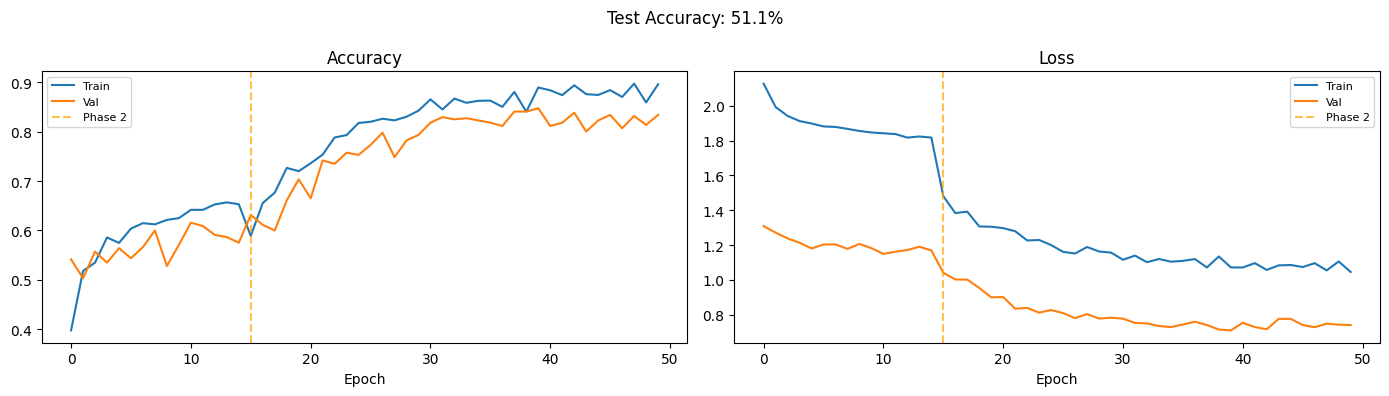

In [59]:
# ── Cell 9: Evaluation + training curves ──────────────────────────────────────
model.load_state_dict(torch.load(MODEL_PATH))
_, test_acc = eval_epoch(model, test_loader)
print(f'Test accuracy: {test_acc:.4f} ({test_acc*100:.1f}%)')

def cat(key, *hists):
    return sum([h[key] for h in hists], [])

p2s = len(hist1['train_acc'])
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
for ax, tr_key, val_key, title in [
    (axes[0], 'train_acc',  'val_acc',  'Accuracy'),
    (axes[1], 'train_loss', 'val_loss', 'Loss'),
]:
    ax.plot(cat(tr_key,  hist1, hist2), label='Train')
    ax.plot(cat(val_key, hist1, hist2), label='Val')
    ax.axvline(p2s, linestyle='--', color='orange', alpha=0.7, label='Phase 2')
    ax.set_title(title); ax.set_xlabel('Epoch'); ax.legend(fontsize=8)

plt.suptitle(f'Test Accuracy: {test_acc*100:.1f}%')
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'training_curves.png'), dpi=150)
plt.show()

In [60]:
# ── Cell 10: Export to ONNX for Mac ───────────────────────────────────────────
model.eval()
dummy     = torch.randn(1, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
onnx_path = os.path.join(OUTPUT_DIR, 'drowsy_model.onnx')

torch.onnx.export(
    model, dummy, onnx_path,
    input_names=['input'],
    output_names=['output'],
    dynamic_axes={'input': {0: 'batch'}, 'output': {0: 'batch'}},
    opset_version=14
)
print(f'ONNX saved: {onnx_path}')
print('Download drowsy_model.onnx + class_labels.json for your Mac!')

/tmp/ipykernel_281628/4187022497.py:6: DeprecationWarning: You are using the legacy TorchScript-based ONNX export. Starting in PyTorch 2.9, the new torch.export-based ONNX exporter will be the default. To switch now, set dynamo=True in torch.onnx.export. This new exporter supports features like exporting LLMs with DynamicCache. We encourage you to try it and share feedback to help improve the experience. Learn more about the new export logic: https://pytorch.org/docs/stable/onnx_dynamo.html. For exporting control flow: https://pytorch.org/tutorials/beginner/onnx/export_control_flow_model_to_onnx_tutorial.html.
  torch.onnx.export(


ONNX saved: /workspace/FaceDetector/output/drowsy_model.onnx
Download drowsy_model.onnx + class_labels.json for your Mac!


In [ ]:
# ── Cell 11: Sample predictions ────────────────────────────────────────────────
with open(LABEL_PATH) as f:
    label_map = {int(k): v for k, v in json.load(f).items()}

model.eval()
indices = random.sample(range(len(test_ds)), min(8, len(test_ds)))
fig, axes = plt.subplots(2, 4, figsize=(16, 8))

for ax, idx in zip(axes.flat, indices):
    img_t, lbl_t = test_ds[idx]
    true = label_map[int(lbl_t.argmax())]
    with torch.no_grad():
        probs = torch.softmax(model(img_t.unsqueeze(0).to(DEVICE)), 1)[0].cpu().numpy()
    top  = int(np.argmax(probs))
    conf = float(probs[top])
    pred = label_map[top] if conf >= CONF_THRESH else 'unknown'
    is_drowsy = pred.lower() in ALERT_LABELS
    display = np.clip(img_t.permute(1,2,0).numpy() * np.array(STD) + np.array(MEAN), 0, 1)
    color = 'red' if is_drowsy else ('green' if pred == true else 'orange')
    ax.imshow(display); ax.axis('off')
    ax.set_title(f'True: {true}\nPred: {pred} {"⚠️" if is_drowsy else ""}\n{conf:.1%}',
                 color=color, fontsize=8)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'sample_predictions.png'), dpi=150)
plt.show()